# Tema 1 · Clusterización — Segmentación de Clientes
## Demo del viernes (resuelto) · Dataset: **Mall Customer Segmentation**

**Caso de negocio.** Un centro comercial quiere entender los distintos
**perfiles de comportamiento** de sus clientes para diseñar campañas de
marketing diferenciadas. No hay etiqueta objetivo: aplicamos **aprendizaje no
supervisado** (K-Means) para descubrir segmentos naturales según ingreso y
comportamiento de gasto.

Pipeline de la demo:
1. Carga y exploración rápida
2. Selección de variables y escalado
3. Elección de K (método del codo + silhouette)
4. Entrenamiento de K-Means
5. Visualización de los clusters
6. Perfilamiento e interpretación de negocio


## 0. Semilla personal (anti-copia)

In [1]:
cedula = 1020304050  # <-- reemplaza por tu número de cédula
import numpy as np
np.random.seed(cedula)
print(f"Semilla fijada en {cedula}")

Semilla fijada en 1020304050


## 1. Carga y exploración rápida

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../../data/02-clusterizacion/Mall_Customers.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Muestreo con la semilla (85%) para que cada estudiante tenga un subconjunto
ligeramente distinto.

In [4]:
df = df.sample(frac=0.85, random_state=cedula).reset_index(drop=True)
print("Dimensiones tras el muestreo:", df.shape)

Dimensiones tras el muestreo: (170, 5)


### Exploración visual rápida
La pareja **Ingreso anual vs. Spending Score** es la más informativa para
segmentar clientes de retail.

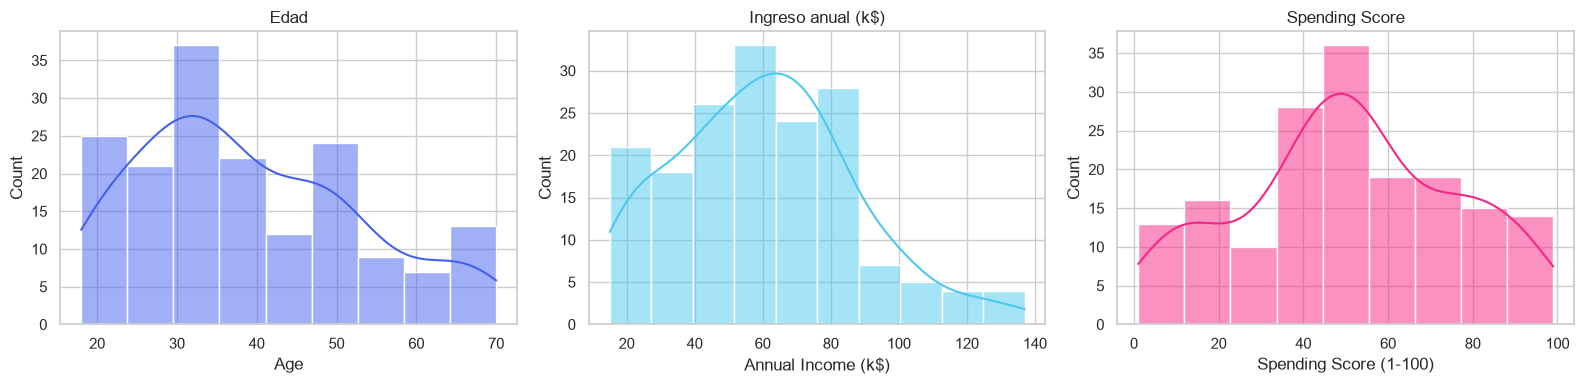

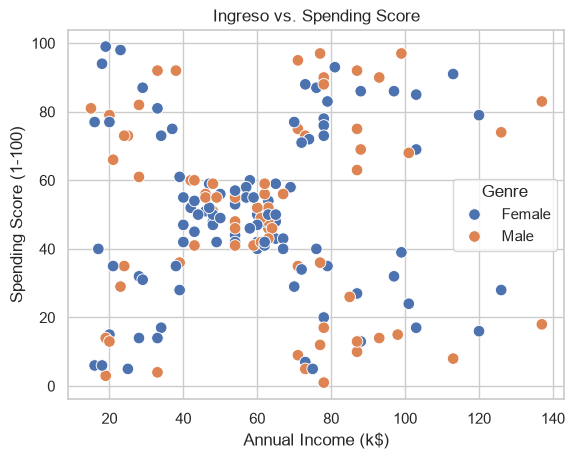

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Age"], kde=True, ax=axes[0], color="#4361ee"); axes[0].set_title("Edad")
sns.histplot(df["Annual Income (k$)"], kde=True, ax=axes[1], color="#4cc9f0"); axes[1].set_title("Ingreso anual (k$)")
sns.histplot(df["Spending Score (1-100)"], kde=True, ax=axes[2], color="#f72585"); axes[2].set_title("Spending Score")
plt.tight_layout(); plt.show()

sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                hue="Genre", s=70)
plt.title("Ingreso vs. Spending Score")
plt.show()

## 2. Selección de variables y escalado

Usaremos **Annual Income** y **Spending Score** (las dos variables con mayor
poder de segmentación y visualizables en 2D). K-Means es sensible a la escala,
así que **estandarizamos** con `StandardScaler`.

In [6]:
from sklearn.preprocessing import StandardScaler

features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Media≈0, std≈1 tras escalar:")
print("means:", X_scaled.mean(axis=0).round(3), "| stds:", X_scaled.std(axis=0).round(3))

Media≈0, std≈1 tras escalar:
means: [ 0. -0.] | stds: [1. 1.]


## 3. Elección de K

Combinamos dos criterios:
- **Método del codo (inercia):** buscamos el "codo" donde añadir clusters deja
  de reducir mucho la inercia.
- **Silhouette score:** mide qué tan bien separados están los clusters
  (más alto = mejor).

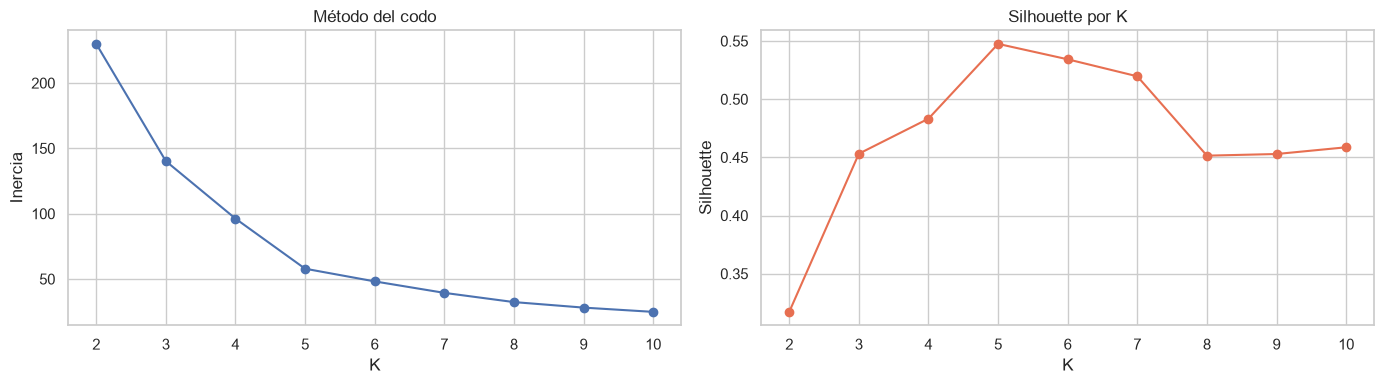

K con mejor silhouette: 5


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, sils, Ks = [], [], range(2, 11)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=cedula, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(Ks), inertias, "o-"); axes[0].set_title("Método del codo")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inercia")
axes[1].plot(list(Ks), sils, "o-", color="#e76f51"); axes[1].set_title("Silhouette por K")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

best_k = list(Ks)[int(np.argmax(sils))]
print("K con mejor silhouette:", best_k)

El codo y el silhouette sugieren **K = 5** para este dataset (patrón clásico
de 5 segmentos de retail). Fijamos K = 5 para la demo.

## 4. Entrenamiento de K-Means

In [8]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=cedula, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
print("Clientes por cluster:")
print(df["Cluster"].value_counts().sort_index())

Clientes por cluster:
Cluster
0    33
1    20
2    27
3    18
4    72
Name: count, dtype: int64


## 5. Visualización de los clusters

Graficamos los clusters en el espacio original (ingreso vs. gasto) y marcamos
los centroides (des-escalados a las unidades originales).

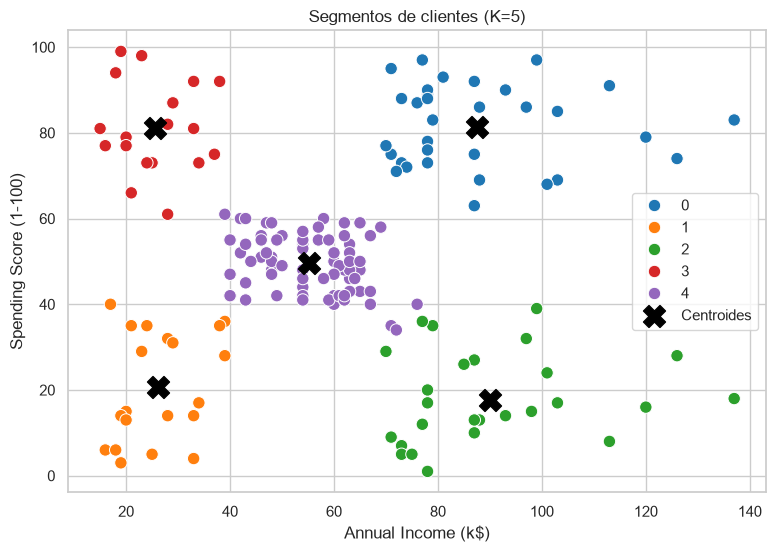

In [9]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                hue="Cluster", palette="tab10", s=80)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=250,
            c="black", label="Centroides")
plt.title(f"Segmentos de clientes (K={k})")
plt.legend()
plt.show()

## 6. Perfilamiento e interpretación de negocio

Resumimos las medias de cada cluster para caracterizarlos.

In [10]:
profile = (df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
             .mean().round(1))
profile["N"] = df["Cluster"].value_counts().sort_index()
profile

,Age,Annual Income (k$),Spending Score (1-100),N
Cluster,,,,
0,32.5,87.4,81.4,33
1,46.2,26.2,20.6,20
2,41.7,89.9,17.7,27
3,25.5,25.6,81.1,18
4,42.2,55.2,49.5,72


### Lectura de negocio (el detalle numérico depende de tu semilla)

Un patrón típico en este dataset son 5 segmentos como:
- **Ingreso alto / gasto alto** → clientes premium, objetivo de fidelización.
- **Ingreso alto / gasto bajo** → potencial no explotado, campañas de activación.
- **Ingreso bajo / gasto alto** → sensibles a promociones, cuidar rentabilidad.
- **Ingreso bajo / gasto bajo** → bajo valor, esfuerzo comercial mínimo.
- **Ingreso medio / gasto medio** → mayoría, mantener experiencia estándar.

**Recomendación:** diseñar una acción de marketing distinta por segmento
(fidelización, activación, promociones dirigidas), en vez de una campaña única
para toda la base.
